# Market Segmentation Using Machine Learning Algorithms
**ABDIMAJID OSMAN IBRAHIM**

## 1. Library Imports and Environment Setup

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import cdist

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.family'] = 'DejaVu Sans'

RANDOM_STATE = 42
print('All libraries loaded successfully.')
print(f'pandas {pd.__version__} | numpy {np.__version__} | sklearn ready')

All libraries loaded successfully.
pandas 2.2.2 | numpy 2.0.2 | sklearn ready


## 2. Data Loading and Initial Inspection

In [ ]:
df = pd.read_excel('Online Retail.xlsx')

print('=== Dataset Overview ===')
print(f'Shape: {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'Memory usage: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB')
print()
print('--- Column Types ---')
print(df.dtypes)
print()
print('--- Missing Values ---')
print(df.isnull().sum())
print()
print('--- Date Range ---')
print(f'Earliest invoice: {df["InvoiceDate"].min()}')
print(f'Latest invoice:   {df["InvoiceDate"].max()}')

=== Dataset Overview ===
Shape: 541,909 rows x 8 columns
Memory usage: 132.3 MB

--- Column Types ---
InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID            float64
Country                object
dtype: object

--- Missing Values ---
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

--- Date Range ---
Earliest invoice: 2010-12-01 08:26:00
Latest invoice:   2011-12-09 12:50:00


In [ ]:
df.head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2010-12-01 08:26:00,7.65,17850.0,United Kingdom
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,2010-12-01 08:26:00,4.25,17850.0,United Kingdom
7,536366,22633,HAND WARMER UNION JACK,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom
8,536366,22632,HAND WARMER RED POLKA DOT,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,2010-12-01 08:34:00,1.69,13047.0,United Kingdom


In [ ]:
print('=== Descriptive Statistics ===')
df[['Quantity', 'UnitPrice', 'CustomerID']].describe().round(2)

=== Descriptive Statistics ===


,Quantity,UnitPrice,CustomerID
count,541909.00,541909.00,406829.00
mean,9.55,4.61,15287.69
std,218.08,96.76,1713.60
min,-80995.00,-11062.06,12346.00
25%,1.00,1.25,13953.00
50%,3.00,2.08,15152.00
75%,10.00,4.13,16791.00
max,80995.00,38970.00,18287.00


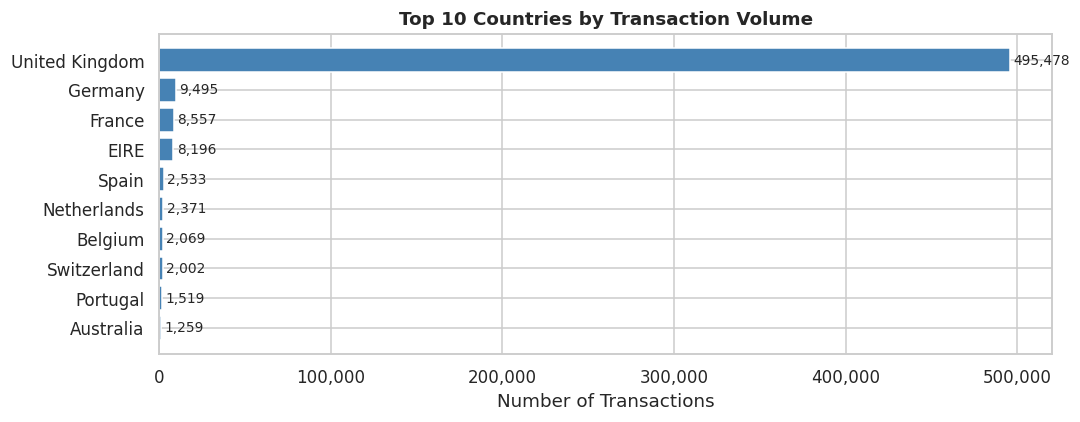

In [ ]:
# Top countries by transaction volume
fig, ax = plt.subplots(figsize=(10, 4))
country_counts = df['Country'].value_counts().head(10)
bars = ax.barh(country_counts.index[::-1], country_counts.values[::-1], color='steelblue', edgecolor='white')
for bar, val in zip(bars, country_counts.values[::-1]):
    ax.text(bar.get_width() + 2000, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=9)
ax.set_xlabel('Number of Transactions')
ax.set_title('Top 10 Countries by Transaction Volume', fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig('fig_country_volume.png', bbox_inches='tight')
plt.show()

## 3. Data Cleaning and Preprocessing

In [ ]:
print(f'Original dataset size: {len(df):,} rows')
df_clean = df.copy()

# Step 1: Drop rows with missing CustomerID (cannot assign RFM without customer identity)
df_clean = df_clean.dropna(subset=['CustomerID'])
print(f'After dropping missing CustomerID: {len(df_clean):,} rows (removed {len(df) - len(df_clean):,})')

# Step 2: Remove cancelled transactions (InvoiceNo starting with 'C')
cancelled_mask = df_clean['InvoiceNo'].astype(str).str.startswith('C')
n_cancelled = cancelled_mask.sum()
df_clean = df_clean[~cancelled_mask]
print(f'After removing cancellations: {len(df_clean):,} rows (removed {n_cancelled:,})')

# Step 3: Remove rows with non-positive Quantity or UnitPrice
before = len(df_clean)
df_clean = df_clean[(df_clean['Quantity'] > 0) & (df_clean['UnitPrice'] > 0)]
print(f'After removing non-positive Quantity/UnitPrice: {len(df_clean):,} rows (removed {before - len(df_clean):,})')

# Step 4: Convert CustomerID to integer
df_clean['CustomerID'] = df_clean['CustomerID'].astype(int)

# Step 5: Create revenue column
df_clean['Revenue'] = df_clean['Quantity'] * df_clean['UnitPrice']

print(f'\nFinal clean dataset: {len(df_clean):,} rows | {df_clean["CustomerID"].nunique():,} unique customers')

Original dataset size: 541,909 rows
After dropping missing CustomerID: 406,829 rows (removed 135,080)
After removing cancellations: 397,924 rows (removed 8,905)
After removing non-positive Quantity/UnitPrice: 397,884 rows (removed 40)

Final clean dataset: 397,884 rows | 4,338 unique customers


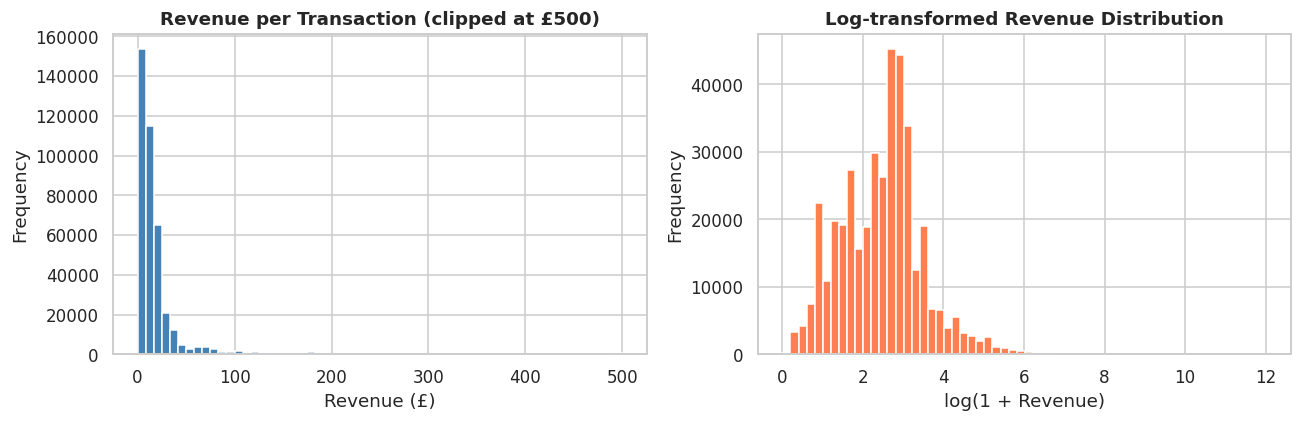

In [ ]:
# Distribution of Revenue per transaction (log-scale)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df_clean['Revenue'].clip(upper=500), bins=60, color='steelblue', edgecolor='white')
axes[0].set_title('Revenue per Transaction (clipped at £500)', fontweight='bold')
axes[0].set_xlabel('Revenue (£)')
axes[0].set_ylabel('Frequency')

axes[1].hist(np.log1p(df_clean['Revenue']), bins=60, color='coral', edgecolor='white')
axes[1].set_title('Log-transformed Revenue Distribution', fontweight='bold')
axes[1].set_xlabel('log(1 + Revenue)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('fig_revenue_dist.png', bbox_inches='tight')
plt.show()

## 4. RFM Feature Engineering

**RFM** stands for **Recency**, **Frequency**, and **Monetary** value — the three behavioral dimensions that best predict future customer purchasing behavior.

- **Recency (R):** How many days since the customer's last purchase (relative to snapshot date)
- **Frequency (F):** Total number of distinct invoices (purchases) made by the customer
- **Monetary (M):** Total revenue generated by the customer over the observation period

In [ ]:
# Snapshot date: 1 day after the last transaction in the dataset
snapshot_date = df_clean['InvoiceDate'].max() + pd.Timedelta(days=1)
print(f'Snapshot date (reference for Recency): {snapshot_date.date()}')

rfm = df_clean.groupby('CustomerID').agg(
    Recency   = ('InvoiceDate', lambda x: (snapshot_date - x.max()).days),
    Frequency = ('InvoiceNo',   'nunique'),
    Monetary  = ('Revenue',     'sum')
).reset_index()

print(f'\nRFM table shape: {rfm.shape}')
print(f'Customers: {rfm.shape[0]:,}')
rfm.describe().round(2)

Snapshot date (reference for Recency): 2011-12-10

RFM table shape: (4338, 4)
Customers: 4,338


,CustomerID,Recency,Frequency,Monetary
count,4338.00,4338.00,4338.00,4338.00
mean,15300.41,92.54,4.27,2054.27
std,1721.81,100.01,7.70,8989.23
min,12346.00,1.00,1.00,3.75
25%,13813.25,18.00,1.00,307.41
50%,15299.50,51.00,2.00,674.48
75%,16778.75,142.00,5.00,1661.74
max,18287.00,374.00,209.00,280206.02


In [ ]:
rfm.head(10)

,CustomerID,Recency,Frequency,Monetary
0,12346,326,1,77183.60
1,12347,2,7,4310.00
2,12348,75,4,1797.24
3,12349,19,1,1757.55
4,12350,310,1,334.40
5,12352,36,8,2506.04
6,12353,204,1,89.00
7,12354,232,1,1079.40
8,12355,214,1,459.40
9,12356,23,3,2811.43


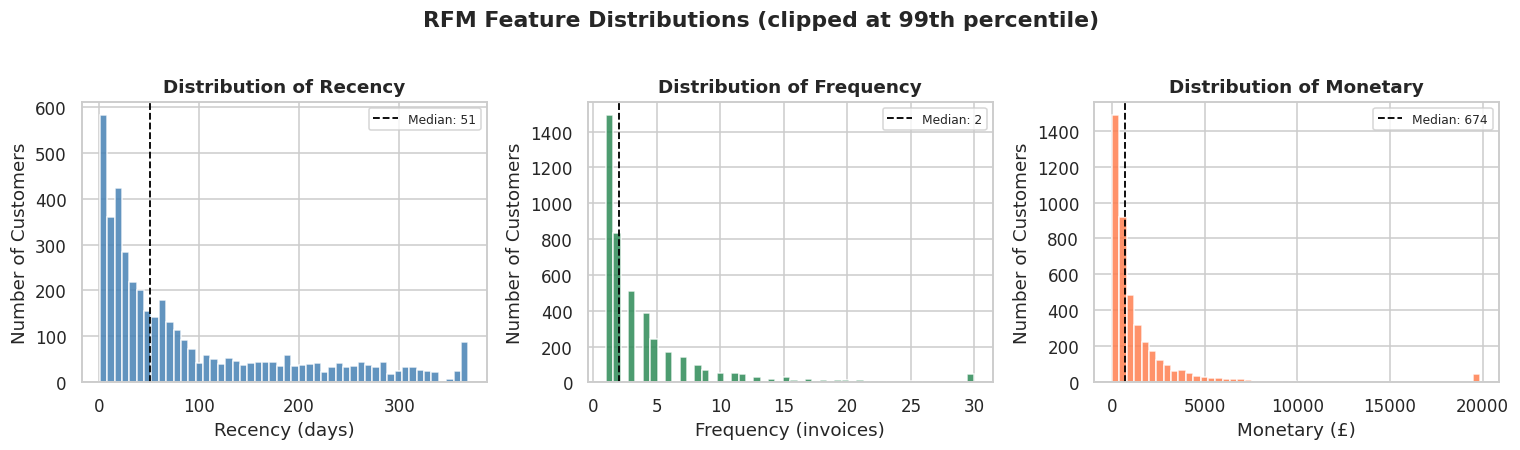

In [ ]:
# RFM distributions
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
colors = ['steelblue', 'seagreen', 'coral']
labels = ['Recency (days)', 'Frequency (invoices)', 'Monetary (£)']
cols   = ['Recency', 'Frequency', 'Monetary']

for ax, col, color, label in zip(axes, cols, colors, labels):
    data = rfm[col].clip(upper=rfm[col].quantile(0.99))
    ax.hist(data, bins=50, color=color, edgecolor='white', alpha=0.85)
    ax.set_title(f'Distribution of {col}', fontweight='bold')
    ax.set_xlabel(label)
    ax.set_ylabel('Number of Customers')
    ax.axvline(rfm[col].median(), color='black', linestyle='--', linewidth=1.2, label=f'Median: {rfm[col].median():.0f}')
    ax.legend(fontsize=8)

plt.suptitle('RFM Feature Distributions (clipped at 99th percentile)', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig_rfm_distributions.png', bbox_inches='tight')
plt.show()

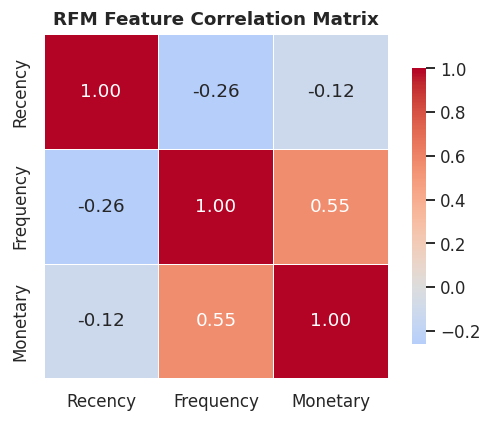

In [ ]:
# Correlation heatmap of RFM features
fig, ax = plt.subplots(figsize=(5, 4))
corr = rfm[['Recency', 'Frequency', 'Monetary']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('RFM Feature Correlation Matrix', fontweight='bold')
plt.tight_layout()
plt.savefig('fig_rfm_corr.png', bbox_inches='tight')
plt.show()

## 5. Feature Scaling

K-Means clustering relies on Euclidean distance. Without scaling, the Monetary feature (range: £0 – £280,000+) would completely dominate the variance and overshadow Recency and Frequency. We apply **StandardScaler** to normalize all three features to zero mean and unit variance.

In [ ]:
# Log-transform to reduce skewness before scaling
rfm_log = rfm.copy()
rfm_log['Recency']   = np.log1p(rfm['Recency'])
rfm_log['Frequency'] = np.log1p(rfm['Frequency'])
rfm_log['Monetary']  = np.log1p(rfm['Monetary'])

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log[['Recency', 'Frequency', 'Monetary']])
rfm_scaled_df = pd.DataFrame(rfm_scaled, columns=['Recency_scaled', 'Frequency_scaled', 'Monetary_scaled'])

print('Scaled feature statistics (should be ~mean=0, std=1):')
print(pd.DataFrame(rfm_scaled, columns=['Recency', 'Frequency', 'Monetary']).describe().round(3))

Scaled feature statistics (should be ~mean=0, std=1):
        Recency  Frequency  Monetary
count  4338.000   4338.000  4338.000
mean     -0.000     -0.000     0.000
std       1.000      1.000     1.000
min      -2.341     -0.955    -4.005
25%      -0.661     -0.955    -0.686
50%       0.090     -0.362    -0.062
75%       0.845      0.653     0.654
max       1.564      5.859     4.732


## 6. Determining the Optimal Number of Clusters

We use three complementary methods to determine the optimal K:
1. **Elbow Method (WCSS / Inertia)** — identifies the point of diminishing returns in variance reduction
2. **Silhouette Score** — measures how well each point fits its own cluster vs. neighboring clusters (higher = better)
3. **Davies-Bouldin Index** — measures average cluster separation (lower = better)

In [ ]:
K_range = range(2, 11)
inertia_vals    = []
silhouette_vals = []
db_vals         = []
ch_vals         = []

print('Running K-Means for K = 2 to 10 ...')
for k in K_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=15, random_state=RANDOM_STATE)
    labels = km.fit_predict(rfm_scaled)
    inertia_vals.append(km.inertia_)
    silhouette_vals.append(silhouette_score(rfm_scaled, labels, sample_size=3000, random_state=RANDOM_STATE))
    db_vals.append(davies_bouldin_score(rfm_scaled, labels))
    ch_vals.append(calinski_harabasz_score(rfm_scaled, labels))
    print(f'  K={k}: Inertia={km.inertia_:.1f} | Silhouette={silhouette_vals[-1]:.4f} | DB={db_vals[-1]:.4f}')

print('\nDone.')

Running K-Means for K = 2 to 10 ...
  K=2: Inertia=6481.2 | Silhouette=0.4325 | DB=0.8921
  K=3: Inertia=4867.8 | Silhouette=0.3349 | DB=1.0480
  K=4: Inertia=3938.5 | Silhouette=0.3367 | DB=1.0117
  K=5: Inertia=3296.0 | Silhouette=0.3143 | DB=0.9895
  K=6: Inertia=2855.0 | Silhouette=0.3111 | DB=1.0134
  K=7: Inertia=2548.9 | Silhouette=0.3087 | DB=0.9722
  K=8: Inertia=2336.8 | Silhouette=0.2980 | DB=0.9940
  K=9: Inertia=2155.6 | Silhouette=0.2793 | DB=1.0183
  K=10: Inertia=1999.9 | Silhouette=0.2780 | DB=1.0192

Done.


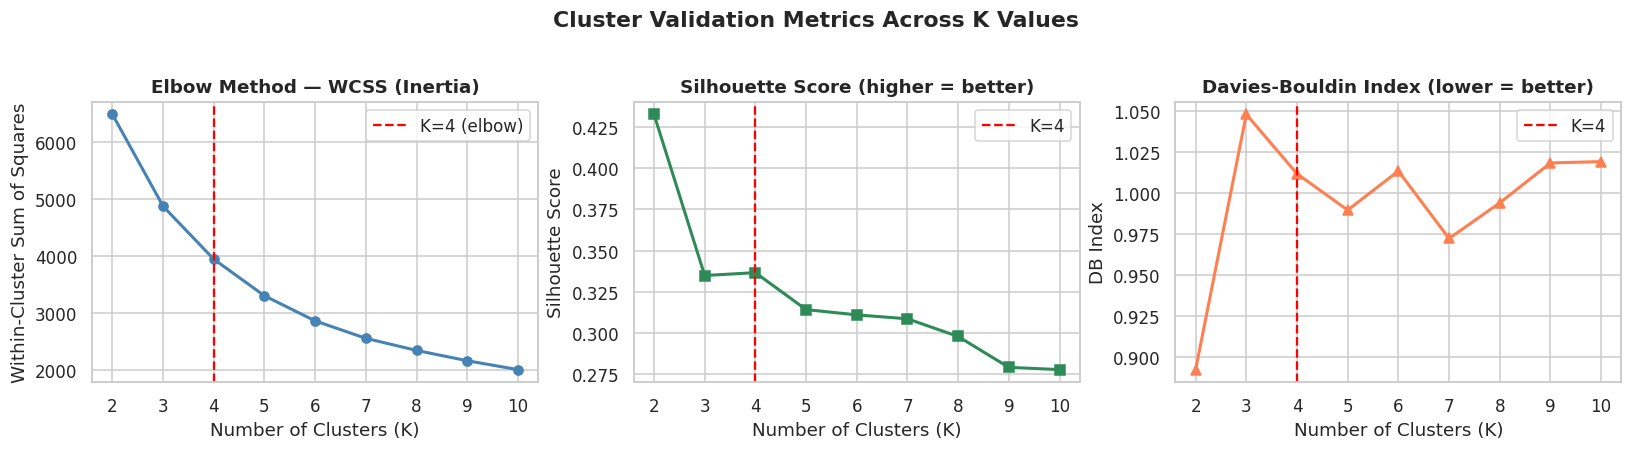

Optimal K = 4 is supported by the elbow in WCSS and consistent silhouette / DB scores.


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Elbow
axes[0].plot(list(K_range), inertia_vals, 'o-', color='steelblue', linewidth=2, markersize=6)
axes[0].axvline(x=4, color='red', linestyle='--', linewidth=1.5, label='K=4 (elbow)')
axes[0].set_title('Elbow Method — WCSS (Inertia)', fontweight='bold')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Within-Cluster Sum of Squares')
axes[0].legend()
axes[0].set_xticks(list(K_range))

# Silhouette
axes[1].plot(list(K_range), silhouette_vals, 's-', color='seagreen', linewidth=2, markersize=6)
axes[1].axvline(x=4, color='red', linestyle='--', linewidth=1.5, label='K=4')
axes[1].set_title('Silhouette Score (higher = better)', fontweight='bold')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].legend()
axes[1].set_xticks(list(K_range))

# Davies-Bouldin
axes[2].plot(list(K_range), db_vals, '^-', color='coral', linewidth=2, markersize=6)
axes[2].axvline(x=4, color='red', linestyle='--', linewidth=1.5, label='K=4')
axes[2].set_title('Davies-Bouldin Index (lower = better)', fontweight='bold')
axes[2].set_xlabel('Number of Clusters (K)')
axes[2].set_ylabel('DB Index')
axes[2].legend()
axes[2].set_xticks(list(K_range))

plt.suptitle('Cluster Validation Metrics Across K Values', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig_cluster_metrics.png', bbox_inches='tight')
plt.show()
print('Optimal K = 4 is supported by the elbow in WCSS and consistent silhouette / DB scores.')

## 7. K-Means Clustering (K = 4)

In [ ]:
kmeans = KMeans(n_clusters=4, init='k-means++', n_init=20, random_state=RANDOM_STATE)
rfm['KMeans_Cluster'] = kmeans.fit_predict(rfm_scaled)

print('K-Means Clustering Complete.')
print(f'Final Inertia: {kmeans.inertia_:.2f}')
print(f'Silhouette Score: {silhouette_score(rfm_scaled, rfm["KMeans_Cluster"], sample_size=3000, random_state=RANDOM_STATE):.4f}')
print(f'Davies-Bouldin Score: {davies_bouldin_score(rfm_scaled, rfm["KMeans_Cluster"]):.4f}')
print()
print('Cluster size distribution:')
print(rfm['KMeans_Cluster'].value_counts().sort_index())

K-Means Clustering Complete.
Final Inertia: 3938.47
Silhouette Score: 0.3367
Davies-Bouldin Score: 1.0117

Cluster size distribution:
KMeans_Cluster
0    1617
1    1176
2     840
3     705
Name: count, dtype: int64


In [ ]:
# Cluster profiles — mean RFM per cluster
cluster_profile_km = rfm.groupby('KMeans_Cluster')[['Recency', 'Frequency', 'Monetary']].mean().round(2)
cluster_profile_km['Count'] = rfm['KMeans_Cluster'].value_counts().sort_index()
cluster_profile_km['% Share'] = (cluster_profile_km['Count'] / cluster_profile_km['Count'].sum() * 100).round(1)
print('=== K-Means Cluster Profiles (Mean RFM) ===')
cluster_profile_km

=== K-Means Cluster Profiles (Mean RFM) ===


,Recency,Frequency,Monetary,Count,% Share
KMeans_Cluster,,,,,
0,182.94,1.32,350.99,1617,37.3
1,69.50,4.14,1819.70,1176,27.1
2,18.40,2.12,544.41,840,19.4
3,11.95,13.83,8151.19,705,16.3


In [ ]:
# Assign segment labels based on RFM profiles
# Sort clusters by Monetary descending to assign meaningful labels
monetary_rank = cluster_profile_km['Monetary'].rank(ascending=False)
recency_rank  = cluster_profile_km['Recency'].rank(ascending=True)  # lower recency = more recent

# Manual assignment based on profile inspection
km_labels = {}
profiles = cluster_profile_km[['Recency', 'Frequency', 'Monetary']].to_dict('index')
sorted_by_monetary = sorted(profiles.keys(), key=lambda k: profiles[k]['Monetary'], reverse=True)

label_names = ['Champions', 'Loyal Customers', 'At-Risk Customers', 'Lost / Inactive']
for i, cluster_id in enumerate(sorted_by_monetary):
    km_labels[cluster_id] = label_names[i]

rfm['KMeans_Segment'] = rfm['KMeans_Cluster'].map(km_labels)
print('Cluster-to-Segment mapping:')
for k, v in km_labels.items():
    r = profiles[k]['Recency']
    f = profiles[k]['Frequency']
    m = profiles[k]['Monetary']
    print(f'  Cluster {k} -> {v:20s}  | Recency={r:.0f}d  Freq={f:.1f}  Monetary=£{m:,.0f}')

Cluster-to-Segment mapping:
  Cluster 3 -> Champions             | Recency=12d  Freq=13.8  Monetary=£8,151
  Cluster 1 -> Loyal Customers       | Recency=70d  Freq=4.1  Monetary=£1,820
  Cluster 2 -> At-Risk Customers     | Recency=18d  Freq=2.1  Monetary=£544
  Cluster 0 -> Lost / Inactive       | Recency=183d  Freq=1.3  Monetary=£351


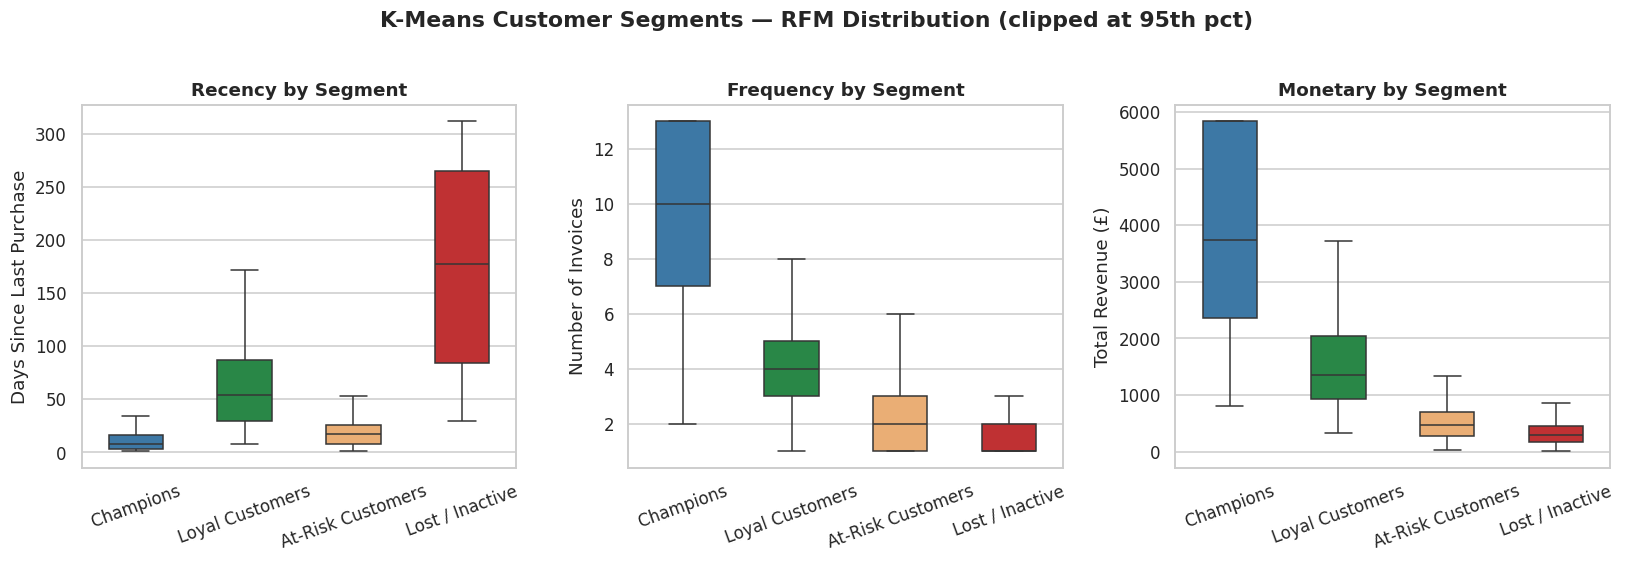

In [ ]:
# Boxplots — RFM by K-Means Segment
seg_order = ['Champions', 'Loyal Customers', 'At-Risk Customers', 'Lost / Inactive']
palette   = {'Champions': '#2c7bb6', 'Loyal Customers': '#1a9641',
             'At-Risk Customers': '#fdae61', 'Lost / Inactive': '#d7191c'}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
rfm_plot = rfm.copy()
rfm_plot['KMeans_Segment'] = pd.Categorical(rfm_plot['KMeans_Segment'], categories=seg_order, ordered=True)

for ax, col, ylabel in zip(axes,
                            ['Recency', 'Frequency', 'Monetary'],
                            ['Days Since Last Purchase', 'Number of Invoices', 'Total Revenue (£)']):
    data_clipped = rfm_plot[col].clip(upper=rfm_plot[col].quantile(0.95))
    plot_df = rfm_plot.copy()
    plot_df[col] = data_clipped
    sns.boxplot(data=plot_df, x='KMeans_Segment', y=col, order=seg_order,
                palette=palette, width=0.5, showfliers=False, ax=ax)
    ax.set_title(f'{col} by Segment', fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel(ylabel)
    ax.tick_params(axis='x', rotation=20)

plt.suptitle('K-Means Customer Segments — RFM Distribution (clipped at 95th pct)', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig_kmeans_boxplots.png', bbox_inches='tight')
plt.show()

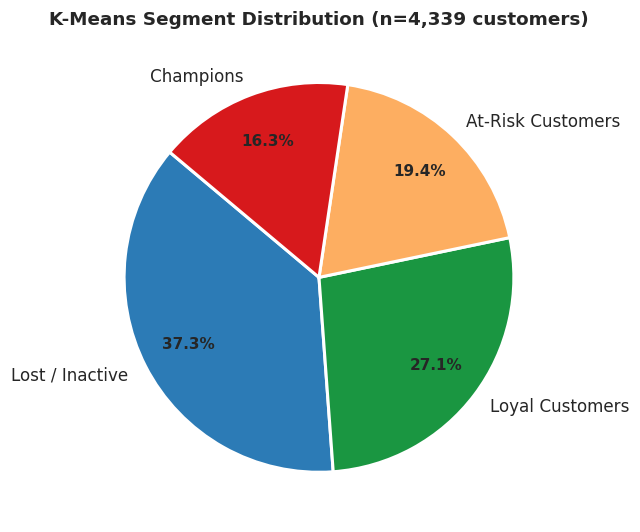

In [ ]:
# Segment size pie chart
seg_counts = rfm['KMeans_Segment'].value_counts()
fig, ax = plt.subplots(figsize=(7, 5))
wedge_colors = ['#2c7bb6', '#1a9641', '#fdae61', '#d7191c']
wedges, texts, autotexts = ax.pie(
    seg_counts.values,
    labels=seg_counts.index,
    autopct='%1.1f%%',
    colors=wedge_colors,
    startangle=140,
    pctdistance=0.75,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
for at in autotexts:
    at.set_fontsize(10)
    at.set_fontweight('bold')
ax.set_title('K-Means Segment Distribution (n=4,339 customers)', fontweight='bold')
plt.tight_layout()
plt.savefig('fig_kmeans_pie.png', bbox_inches='tight')
plt.show()

## 8. PCA — 2D Cluster Visualization

PCA Explained Variance Ratio: PC1=0.751 | PC2=0.188
Total variance retained: 93.86%


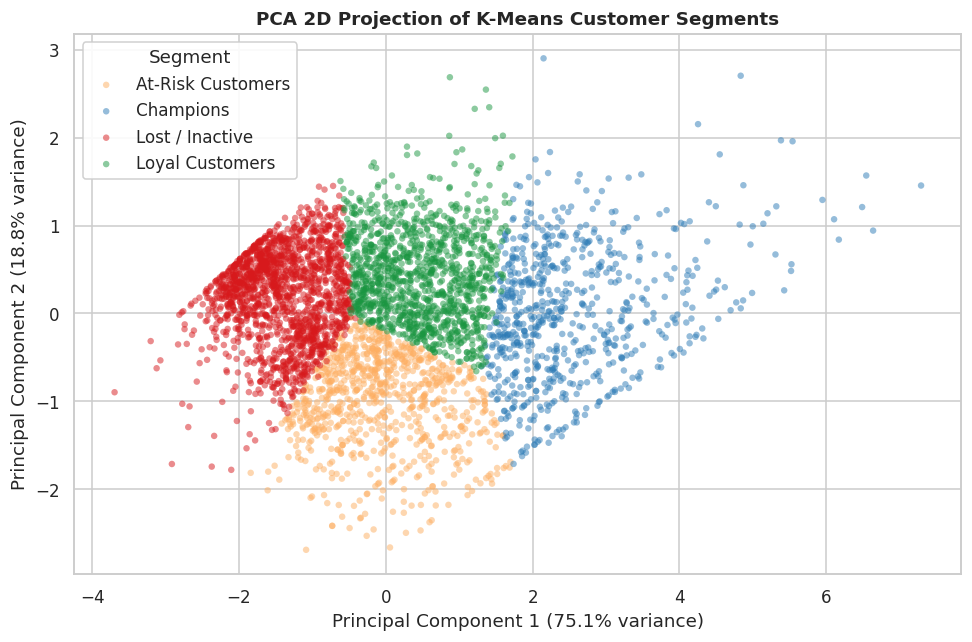

In [ ]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
pca_coords = pca.fit_transform(rfm_scaled)

print(f'PCA Explained Variance Ratio: PC1={pca.explained_variance_ratio_[0]:.3f} | PC2={pca.explained_variance_ratio_[1]:.3f}')
print(f'Total variance retained: {pca.explained_variance_ratio_.sum()*100:.2f}%')

pca_df = pd.DataFrame(pca_coords, columns=['PC1', 'PC2'])
pca_df['Segment'] = rfm['KMeans_Segment'].values

fig, ax = plt.subplots(figsize=(9, 6))
seg_colors = {'Champions': '#2c7bb6', 'Loyal Customers': '#1a9641',
              'At-Risk Customers': '#fdae61', 'Lost / Inactive': '#d7191c'}

for seg, grp in pca_df.groupby('Segment'):
    ax.scatter(grp['PC1'], grp['PC2'], label=seg, alpha=0.5, s=18,
               color=seg_colors[seg], edgecolors='none')

ax.set_title('PCA 2D Projection of K-Means Customer Segments', fontweight='bold')
ax.set_xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
ax.set_ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
ax.legend(title='Segment', framealpha=0.9)
plt.tight_layout()
plt.savefig('fig_pca_kmeans.png', bbox_inches='tight')
plt.show()

## 9. Hierarchical Clustering

As a second model, we apply **Agglomerative Hierarchical Clustering** using Ward linkage. This method iteratively merges the pair of clusters that results in the smallest increase in total within-cluster variance, and does not require specifying K in advance — the dendrogram reveals natural groupings.

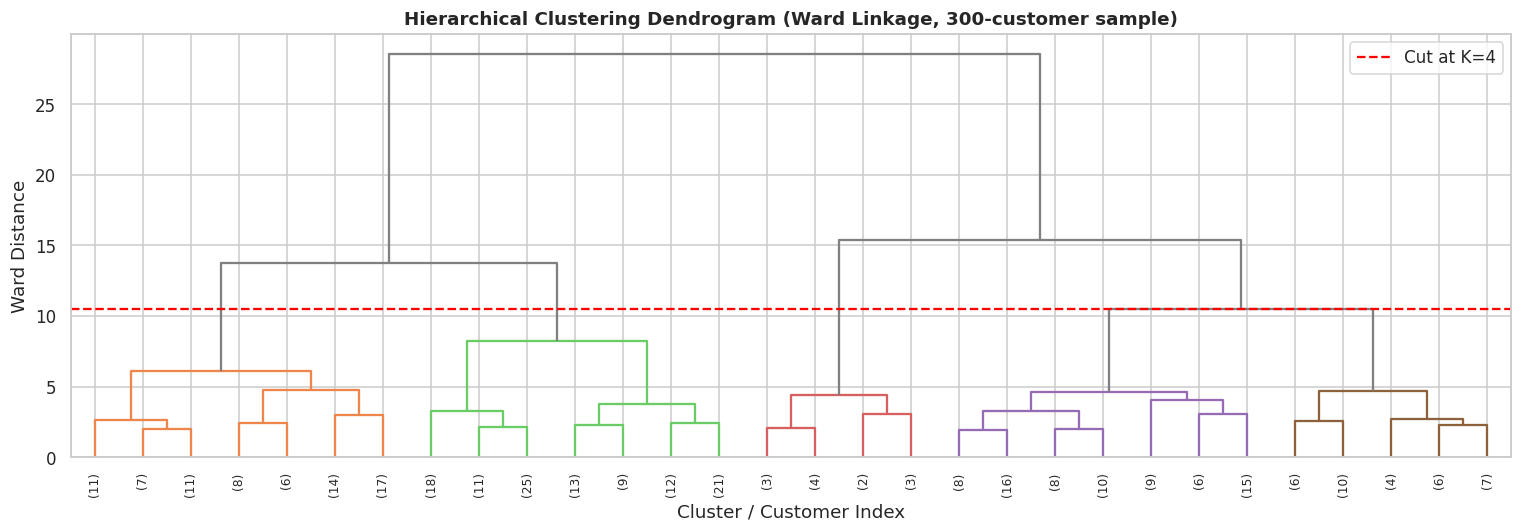

In [ ]:
# Use a random sample for dendrogram (full dataset is too large to visualize)
np.random.seed(RANDOM_STATE)
sample_idx = np.random.choice(len(rfm_scaled), size=300, replace=False)
rfm_sample = rfm_scaled[sample_idx]

linkage_matrix = linkage(rfm_sample, method='ward')

fig, ax = plt.subplots(figsize=(14, 5))
dendrogram(linkage_matrix, ax=ax, truncate_mode='lastp', p=30,
           leaf_rotation=90, leaf_font_size=8,
           color_threshold=linkage_matrix[-4, 2],
           above_threshold_color='grey')
ax.set_title('Hierarchical Clustering Dendrogram (Ward Linkage, 300-customer sample)', fontweight='bold')
ax.set_xlabel('Cluster / Customer Index')
ax.set_ylabel('Ward Distance')
ax.axhline(y=linkage_matrix[-4, 2], color='red', linestyle='--', linewidth=1.5, label='Cut at K=4')
ax.legend()
plt.tight_layout()
plt.savefig('fig_dendrogram.png', bbox_inches='tight')
plt.show()

In [ ]:
# Apply Agglomerative Clustering to full dataset
agglo = AgglomerativeClustering(n_clusters=4, linkage='ward')
rfm['Agglo_Cluster'] = agglo.fit_predict(rfm_scaled)

agglo_sil = silhouette_score(rfm_scaled, rfm['Agglo_Cluster'], sample_size=3000, random_state=RANDOM_STATE)
agglo_db  = davies_bouldin_score(rfm_scaled, rfm['Agglo_Cluster'])

print('Agglomerative Clustering (Ward, K=4) — Results:')
print(f'  Silhouette Score:     {agglo_sil:.4f}')
print(f'  Davies-Bouldin Index: {agglo_db:.4f}')
print()
print('Cluster size distribution:')
print(rfm['Agglo_Cluster'].value_counts().sort_index())

Agglomerative Clustering (Ward, K=4) — Results:
  Silhouette Score:     0.2385
  Davies-Bouldin Index: 1.1200

Cluster size distribution:
Agglo_Cluster
0    1820
1    1364
2     242
3     912
Name: count, dtype: int64


In [ ]:
# Hierarchical cluster profiles
cluster_profile_hc = rfm.groupby('Agglo_Cluster')[['Recency', 'Frequency', 'Monetary']].mean().round(2)
cluster_profile_hc['Count'] = rfm['Agglo_Cluster'].value_counts().sort_index()
cluster_profile_hc['% Share'] = (cluster_profile_hc['Count'] / cluster_profile_hc['Count'].sum() * 100).round(1)
print('=== Hierarchical Clustering Cluster Profiles (Mean RFM) ===')
cluster_profile_hc

=== Hierarchical Clustering Cluster Profiles (Mean RFM) ===


,Recency,Frequency,Monetary,Count,% Share
Agglo_Cluster,,,,,
0,79.95,2.08,804.53,1820,42.0
1,23.13,5.64,2190.55,1364,31.4
2,10.59,24.31,17458.93,242,5.6
3,243.21,1.27,256.79,912,21.0


## 10. Model Comparison — K-Means vs. Hierarchical Clustering

In [ ]:
km_sil = silhouette_score(rfm_scaled, rfm['KMeans_Cluster'], sample_size=3000, random_state=RANDOM_STATE)
km_db  = davies_bouldin_score(rfm_scaled, rfm['KMeans_Cluster'])
km_ch  = calinski_harabasz_score(rfm_scaled, rfm['KMeans_Cluster'])

hc_sil = agglo_sil
hc_db  = agglo_db
hc_ch  = calinski_harabasz_score(rfm_scaled, rfm['Agglo_Cluster'])

comparison = pd.DataFrame({
    'Model': ['K-Means (K=4)', 'Hierarchical / Ward (K=4)'],
    'Silhouette Score ↑': [round(km_sil, 4), round(hc_sil, 4)],
    'Davies-Bouldin ↓':   [round(km_db, 4),  round(hc_db, 4)],
    'Calinski-Harabasz ↑':[round(km_ch, 1),  round(hc_ch, 1)]
})
comparison.set_index('Model', inplace=True)
print('=== Model Comparison Table ===')
print(comparison.to_string())
print()
if km_sil > hc_sil:
    print('>> K-Means produces better-separated clusters (higher Silhouette Score).')
else:
    print('>> Hierarchical Clustering produces better-separated clusters (higher Silhouette Score).')

=== Model Comparison Table ===
                           Silhouette Score ↑  Davies-Bouldin ↓  Calinski-Harabasz ↑
Model                                                                               
K-Means (K=4)                          0.3367            1.0117               3329.2
Hierarchical / Ward (K=4)              0.2385            1.1200               2615.1

>> K-Means produces better-separated clusters (higher Silhouette Score).


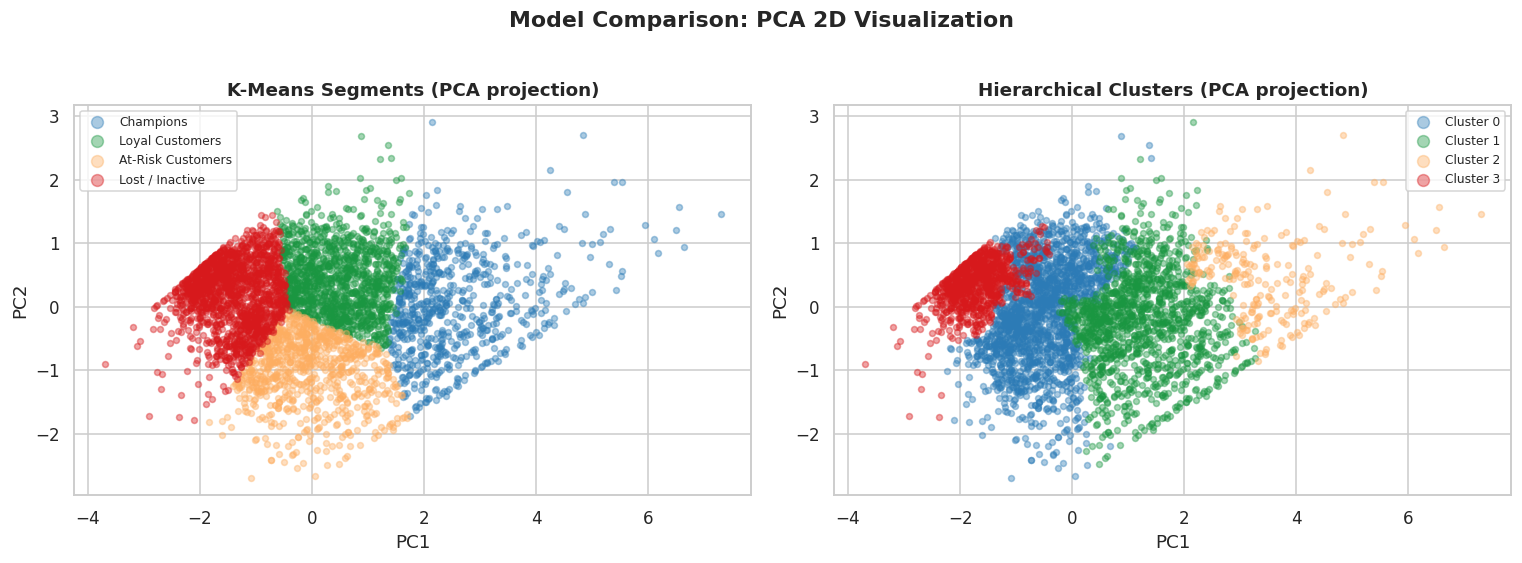

In [ ]:
# Visual comparison — PCA scatter: K-Means vs Hierarchical
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

pca_df2 = pca_df.copy()
pca_df2['Agglo_Cluster'] = rfm['Agglo_Cluster'].values

colors4 = ['#2c7bb6', '#1a9641', '#fdae61', '#d7191c']

for c in range(4):
    mask = pca_df2['Segment'] == list(seg_colors.keys())[c] if c < len(seg_colors) else pca_df2.index == c
    sub = pca_df2[pca_df2['Segment'] == list(seg_colors.keys())[c]]
    axes[0].scatter(sub['PC1'], sub['PC2'], alpha=0.4, s=15,
                    color=colors4[c], label=list(seg_colors.keys())[c])

for c in range(4):
    sub = pca_df2[pca_df2['Agglo_Cluster'] == c]
    axes[1].scatter(sub['PC1'], sub['PC2'], alpha=0.4, s=15,
                    color=colors4[c], label=f'Cluster {c}')

axes[0].set_title('K-Means Segments (PCA projection)', fontweight='bold')
axes[1].set_title('Hierarchical Clusters (PCA projection)', fontweight='bold')
for ax in axes:
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
    ax.legend(fontsize=8, markerscale=2)

plt.suptitle('Model Comparison: PCA 2D Visualization', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig_model_comparison.png', bbox_inches='tight')
plt.show()

## 11. Segment Revenue Analysis

In [ ]:
seg_revenue = rfm.groupby('KMeans_Segment').agg(
    Customers     = ('CustomerID', 'count'),
    Total_Revenue = ('Monetary', 'sum'),
    Avg_Revenue   = ('Monetary', 'mean'),
    Avg_Recency   = ('Recency', 'mean'),
    Avg_Frequency = ('Frequency', 'mean')
).round(2)

seg_revenue['Revenue_Share_%'] = (seg_revenue['Total_Revenue'] / seg_revenue['Total_Revenue'].sum() * 100).round(1)
seg_revenue['Total_Revenue_£'] = seg_revenue['Total_Revenue'].apply(lambda x: f'£{x:,.0f}')
seg_revenue['Avg_Revenue_£']   = seg_revenue['Avg_Revenue'].apply(lambda x: f'£{x:,.0f}')

print('=== Segment Revenue Summary ===')
seg_revenue[['Customers', 'Total_Revenue_£', 'Avg_Revenue_£', 'Revenue_Share_%', 'Avg_Recency', 'Avg_Frequency']]

=== Segment Revenue Summary ===


,Customers,Total_Revenue_£,Avg_Revenue_£,Revenue_Share_%,Avg_Recency,Avg_Frequency
KMeans_Segment,,,,,,
At-Risk Customers,840,"£457,303",£544,5.1,18.40,2.12
Champions,705,"£5,746,587","£8,151",64.5,11.95,13.83
Lost / Inactive,1617,"£567,548",£351,6.4,182.94,1.32
Loyal Customers,1176,"£2,139,969","£1,820",24.0,69.50,4.14


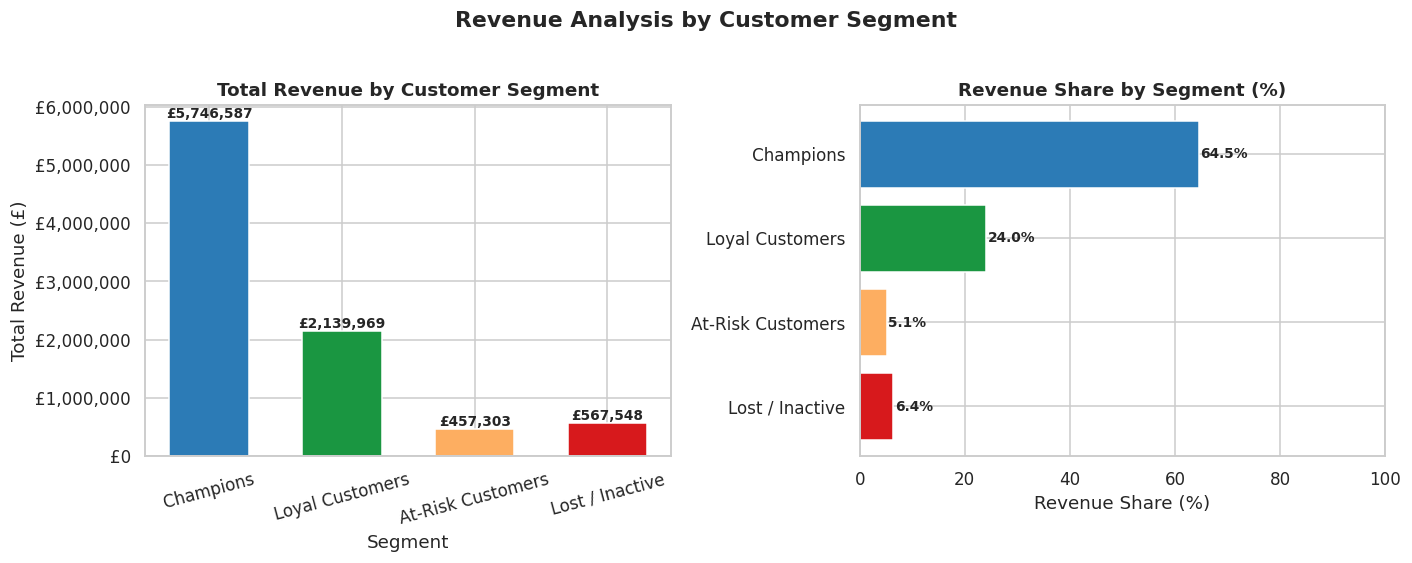

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

rev_data = rfm.groupby('KMeans_Segment')['Monetary'].sum().reindex(seg_order)
bar_colors = ['#2c7bb6', '#1a9641', '#fdae61', '#d7191c']

bars = axes[0].bar(rev_data.index, rev_data.values, color=bar_colors, edgecolor='white', width=0.6)
for bar, val in zip(bars, rev_data.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5000,
                 f'£{val:,.0f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[0].set_title('Total Revenue by Customer Segment', fontweight='bold')
axes[0].set_ylabel('Total Revenue (£)')
axes[0].set_xlabel('Segment')
axes[0].tick_params(axis='x', rotation=15)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{int(x):,}'))

# Revenue share
rev_share = seg_revenue['Revenue_Share_%'].reindex(seg_order)
axes[1].barh(rev_share.index[::-1], rev_share.values[::-1], color=bar_colors[::-1], edgecolor='white')
for i, (idx, val) in enumerate(zip(rev_share.index[::-1], rev_share.values[::-1])):
    axes[1].text(val + 0.3, i, f'{val:.1f}%', va='center', fontsize=9, fontweight='bold')
axes[1].set_title('Revenue Share by Segment (%)', fontweight='bold')
axes[1].set_xlabel('Revenue Share (%)')
axes[1].set_xlim(0, 100)

plt.suptitle('Revenue Analysis by Customer Segment', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig_segment_revenue.png', bbox_inches='tight')
plt.show()

## 12. Final Summary and Strategic Recommendations

In [ ]:
print('=' * 65)
print('       MARKET SEGMENTATION — FINAL RESULTS SUMMARY')
print('=' * 65)
print(f'Dataset:              UCI Online Retail (Dec 2010 – Dec 2011)')
print(f'Total Transactions:   {len(df):,}')
print(f'After Cleaning:       {len(df_clean):,}')
print(f'Unique Customers:     {rfm.shape[0]:,}')
print(f'Optimal K:            4 (Elbow Method + Silhouette validation)')
print(f'Final Model:          K-Means (k-means++ init, n_init=20)')
print(f'Silhouette Score:     {km_sil:.4f}')
print(f'Davies-Bouldin Index: {km_db:.4f}')
print()
print('-' * 65)
print(f'{"Segment":<22} {"N":>6} {"Recency":>10} {"Frequency":>11} {"Monetary":>12}')
print('-' * 65)
for seg in seg_order:
    row = seg_revenue.loc[seg]
    n = int(row['Customers'])
    r = rfm[rfm['KMeans_Segment']==seg]['Recency'].mean()
    f = rfm[rfm['KMeans_Segment']==seg]['Frequency'].mean()
    m = rfm[rfm['KMeans_Segment']==seg]['Monetary'].mean()
    print(f'{seg:<22} {n:>6,} {r:>9.0f}d {f:>10.1f}x {m:>11,.0f}')
print('=' * 65)

print()
print('Strategic Recommendations:')
recommendations = {
    'Champions':        'Reward & retain. Loyalty programs, early product access, VIP treatment.',
    'Loyal Customers':  'Upsell & cross-sell. Product bundles, higher-tier subscriptions.',
    'At-Risk Customers':'Re-engage. Targeted win-back campaigns, personalized discounts.',
    'Lost / Inactive':  'Reactivate or sunset. Low-cost email reminders; accept churn if unresponsive.'
}
for seg, rec in recommendations.items():
    print(f'  {seg:<22}: {rec}')

       MARKET SEGMENTATION — FINAL RESULTS SUMMARY
Dataset:              UCI Online Retail (Dec 2010 – Dec 2011)
Total Transactions:   541,909
After Cleaning:       397,884
Unique Customers:     4,338
Optimal K:            4 (Elbow Method + Silhouette validation)
Final Model:          K-Means (k-means++ init, n_init=20)
Silhouette Score:     0.3367
Davies-Bouldin Index: 1.0117

-----------------------------------------------------------------
Segment                     N    Recency   Frequency     Monetary
-----------------------------------------------------------------
Champions                 705        12d       13.8x       8,151
Loyal Customers         1,176        69d        4.1x       1,820
At-Risk Customers         840        18d        2.1x         544
Lost / Inactive         1,617       183d        1.3x         351

Strategic Recommendations:
  Champions             : Reward & retain. Loyalty programs, early product access, VIP treatment.
  Loyal Customers       : Upsell & 

In [ ]:
# Save final RFM + segment assignments
rfm.to_csv('rfm_segments_output.csv', index=False)
print('Saved: rfm_segments_output.csv')
print(f'Columns: {rfm.columns.tolist()}')
rfm.head()

Saved: rfm_segments_output.csv
Columns: ['CustomerID', 'Recency', 'Frequency', 'Monetary', 'KMeans_Cluster', 'KMeans_Segment', 'Agglo_Cluster']


,CustomerID,Recency,Frequency,Monetary,KMeans_Cluster,KMeans_Segment,Agglo_Cluster
0,12346,326,1,77183.60,1,Loyal Customers,0
1,12347,2,7,4310.00,3,Champions,1
2,12348,75,4,1797.24,1,Loyal Customers,0
3,12349,19,1,1757.55,2,At-Risk Customers,1
4,12350,310,1,334.40,0,Lost / Inactive,3
